<a href="https://colab.research.google.com/github/marciapaulasv-coder/TechChalenge/blob/main/01_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. Visão Geral**

**Importação das Bibliotecas**

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn import*


In [ ]:
pip install plotly_express

In [ ]:
import plotly.express as px

**Carregamento das Bases**

In [ ]:
AR = pd.read_csv("application_record.csv", sep = ",")
CR = pd.read_csv("credit_record.csv", sep = ",")

**Análise das Bases**

In [ ]:
AR.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


In [ ]:
CR.head()

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [ ]:
AR.shape

(438557, 18)

In [ ]:
CR.shape

(1048575, 3)

In [ ]:
AR.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL       

In [ ]:
CR.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   ID              1048575 non-null  int64 
 1   MONTHS_BALANCE  1048575 non-null  int64 
 2   STATUS          1048575 non-null  object
dtypes: int64(2), object(1)
memory usage: 24.0+ MB


In [ ]:
AR.dtypes

,0
ID,int64
CODE_GENDER,object
FLAG_OWN_CAR,object
FLAG_OWN_REALTY,object
CNT_CHILDREN,int64
AMT_INCOME_TOTAL,float64
NAME_INCOME_TYPE,object
NAME_EDUCATION_TYPE,object
NAME_FAMILY_STATUS,object
NAME_HOUSING_TYPE,object


In [ ]:
CR.dtypes

,0
ID,int64
MONTHS_BALANCE,int64
STATUS,object


In [ ]:
AR.describe()

,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS
count,4.385570e+05,438557.000000,4.385570e+05,438557.000000,438557.000000,438557.0,438557.000000,438557.000000,438557.000000,438557.000000
mean,6.022176e+06,0.427390,1.875243e+05,-15997.904649,60563.675328,1.0,0.206133,0.287771,0.108207,2.194465
std,5.716370e+05,0.724882,1.100869e+05,4185.030007,138767.799647,0.0,0.404527,0.452724,0.310642,0.897207
min,5.008804e+06,0.000000,2.610000e+04,-25201.000000,-17531.000000,1.0,0.000000,0.000000,0.000000,1.000000
25%,5.609375e+06,0.000000,1.215000e+05,-19483.000000,-3103.000000,1.0,0.000000,0.000000,0.000000,2.000000
50%,6.047745e+06,0.000000,1.607805e+05,-15630.000000,-1467.000000,1.0,0.000000,0.000000,0.000000,2.000000
75%,6.456971e+06,1.000000,2.250000e+05,-12514.000000,-371.000000,1.0,0.000000,1.000000,0.000000,3.000000
max,7.999952e+06,19.000000,6.750000e+06,-7489.000000,365243.000000,1.0,1.000000,1.000000,1.000000,20.000000


In [ ]:
CR.describe()

,ID,MONTHS_BALANCE
count,1.048575e+06,1.048575e+06
mean,5.068286e+06,-1.913700e+01
std,4.615058e+04,1.402350e+01
min,5.001711e+06,-6.000000e+01
25%,5.023644e+06,-2.900000e+01
50%,5.062104e+06,-1.700000e+01
75%,5.113856e+06,-7.000000e+00
max,5.150487e+06,0.000000e+00


In [ ]:
AR['ID'].nunique()

438510

In [ ]:
CR['ID'].nunique()

45985

In [ ]:
Comum_ID = len(set(AR['ID']) & set(CR['ID']))
print(Comum_ID)

36457


**Conclusão:** 36.457 clientes estão presentes nas duas bases - CR e AR. Esses clientes serão utilizados nas próximas análises.

**Contagem de Valores Nulos nas colunas**

In [ ]:
AR.isnull().sum().sort_values(ascending = False)

,0
OCCUPATION_TYPE,134203
ID,0
CODE_GENDER,0
FLAG_OWN_CAR,0
CNT_CHILDREN,0
FLAG_OWN_REALTY,0
NAME_INCOME_TYPE,0
NAME_EDUCATION_TYPE,0
NAME_FAMILY_STATUS,0
AMT_INCOME_TOTAL,0


<Axes: >

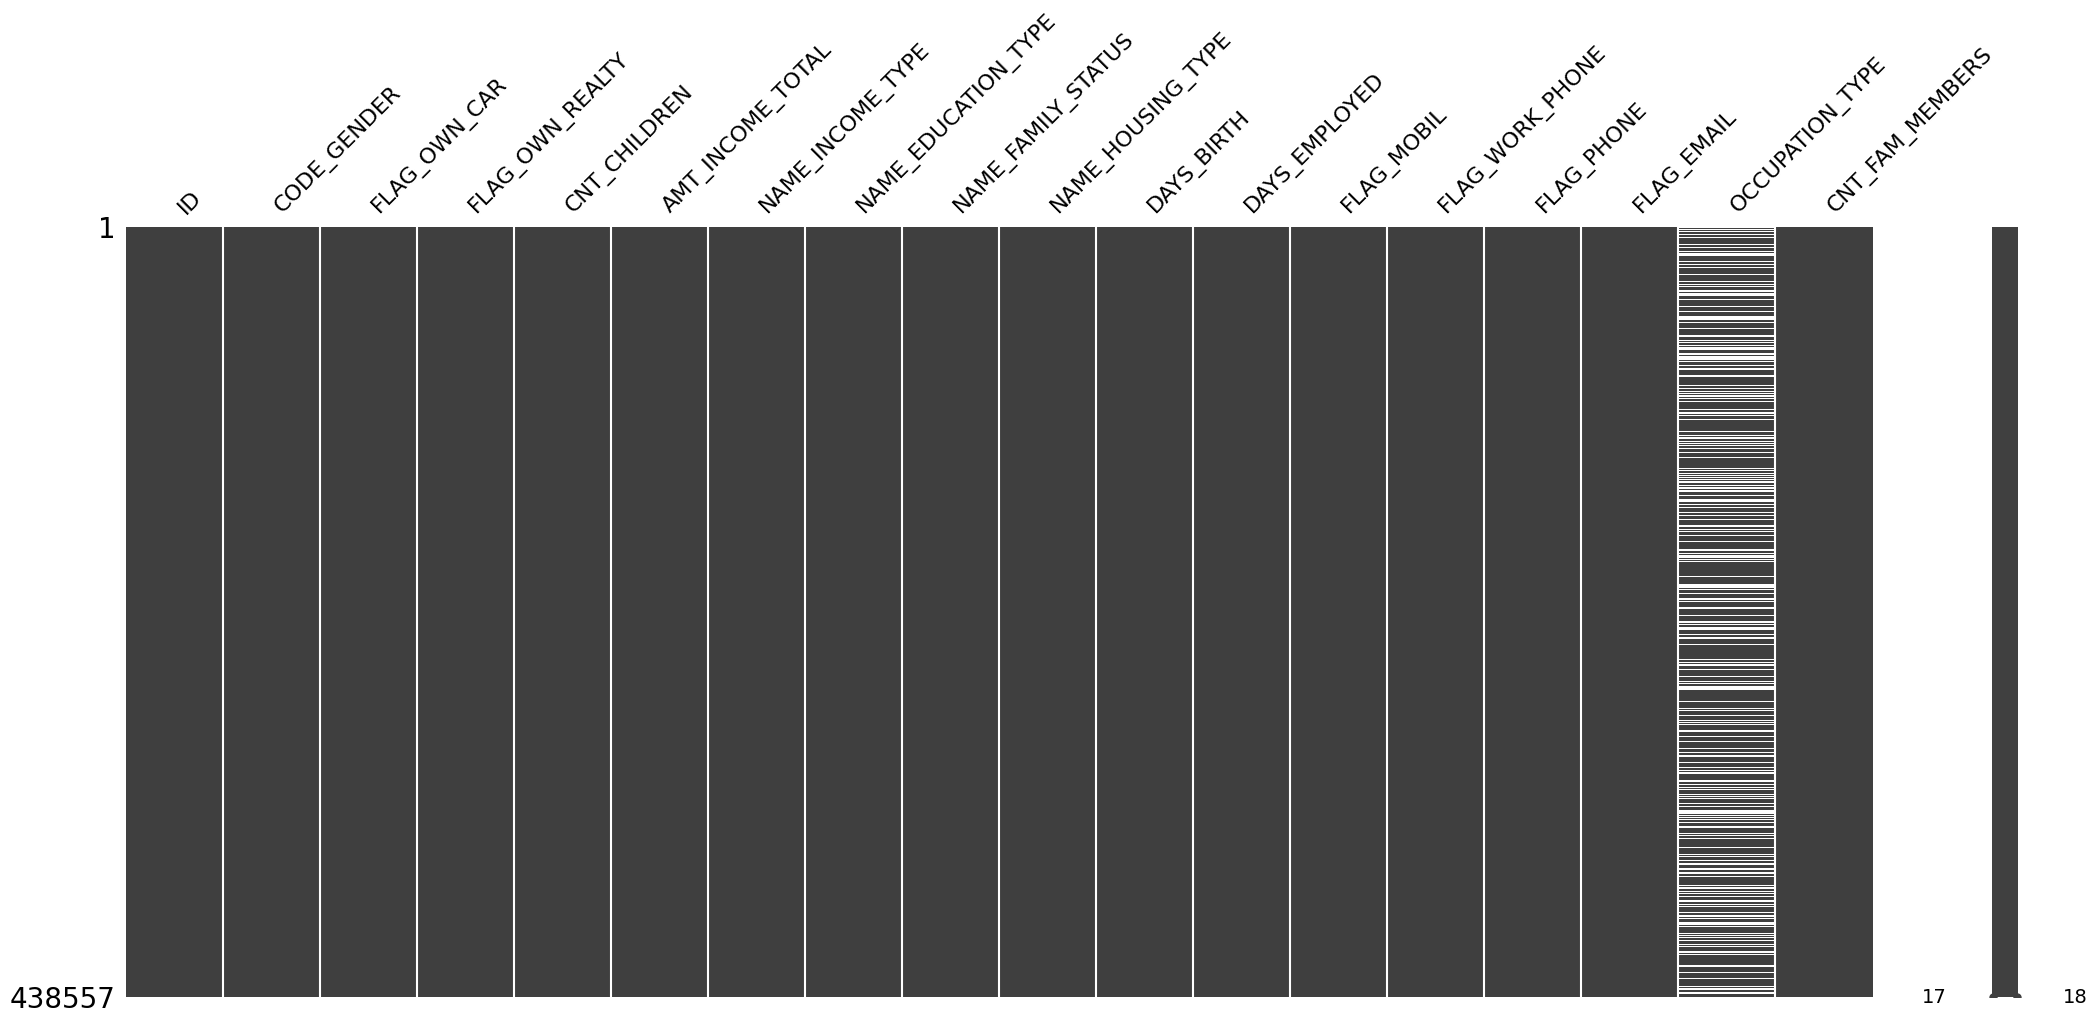

In [ ]:
msno.matrix(AR)

In [ ]:
ocupacao_nulos = AR[AR['OCCUPATION_TYPE'].isnull()]['NAME_INCOME_TYPE']

pd.DataFrame({
    'Quantidade': ocupacao_nulos.value_counts(),
    'Percentual (%)': ocupacao_nulos.value_counts(normalize=True).mul(100).round(2)
})

,Quantidade,Percentual (%)
NAME_INCOME_TYPE,,
Pensioner,75357,56.15
Working,35886,26.74
Commercial associate,16745,12.48
State servant,6210,4.63
Student,5,0.00


**Conclusão:** a variável "Tipo de ocupação" apresenta muitos valores nulos. Comparando com a coluna da renda, observa-se que entre esses registros, 56,15% correspondem a pensionistas, seguidos por trabalhadores (26,74%).

**Dicionário da Variável Status**

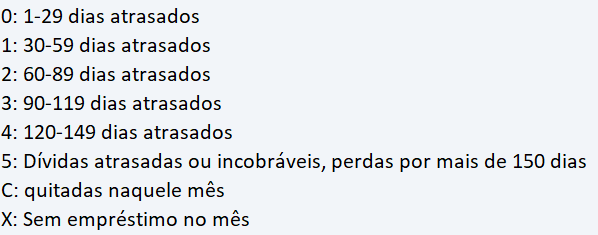

In [ ]:
CR['STATUS'].value_counts(dropna=False)

,count
STATUS,
C,442031
0,383120
X,209230
1,11090
5,1693
2,868
3,320
4,223


In [ ]:
(CR['STATUS'].value_counts(normalize=True) * 100).round(2)

,proportion
STATUS,
C,42.16
0,36.54
X,19.95
1,1.06
5,0.16
2,0.08
3,0.03
4,0.02


In [ ]:
CR['ATRASO>30'] = CR['STATUS'].isin(['1', '2', '3', '4', '5']).astype(int)

CR['ATRASO>60'] = CR['STATUS'].isin(['2', '3', '4', '5']).astype(int)

In [ ]:
comparacao_target = CR.groupby('ID')[['ATRASO>30', 'ATRASO>60']].max()

In [ ]:
comparacao_target.sum()

,0
ATRASO>30,5350
ATRASO>60,667


In [ ]:
(comparacao_target.mean() * 100).round(2)

,0
ATRASO>30,11.63
ATRASO>60,1.45


**Conclusão:** o critério de atraso superior a 60 dias identifica apenas 1,45% dos clientes, gerando uma base muito pequena. Por isso, foi adotado como TARGET o atraso igual ou superior a 30 dias, que representa 11,63% dos clientes e oferece uma quantidade maior de exemplos de "mau pagadores" para a modelagem.

In [ ]:
CR['TARGET'] = CR['STATUS'].isin(['1', '2', '3', '4', '5']).astype(int)

**Conclusão:**  *Target 0* - Bom Pagador    *Target 1* - Mau Pagador

In [ ]:
target_cliente = CR.groupby('ID')['TARGET'].max().reset_index()
target_cliente.head()

,ID,TARGET
0,5001711,0
1,5001712,0
2,5001713,0
3,5001714,0
4,5001715,0


Para estabelecer o Target do cliente, foram analisados todos os meses em que ele aparece na base. Foi considerado o maior valor de Target, ou seja, se em pelo menos um dos meses o cliente aparece com target=1, ele será considerado "mau pagador".

In [ ]:
df = AR.merge(target_cliente, on='ID', how='inner')
df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,1
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,1
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,0


Foram mantidos apenas os clientes presentes nas duas bases. Base final: 36.457 clientes.

In [ ]:
historico_clientes = df[['ID', 'TARGET']].merge(CR.groupby('ID')['MONTHS_BALANCE'].count().reset_index(), on='ID', how='left')
historico_clientes.head()

,ID,TARGET,MONTHS_BALANCE
0,5008804,1,16
1,5008805,1,15
2,5008806,0,30
3,5008808,0,5
4,5008809,0,5


Quantidade de meses do histórico que a base traz para cada cliente.

In [ ]:
historico_clientes.shape

(36457, 3)

In [ ]:
historico_clientes.groupby('TARGET')['MONTHS_BALANCE'].agg(['count', 'mean', 'median']).round(2)

,count,mean,median
TARGET,,,
0,32166,20.77,17.0
1,4291,25.53,23.0


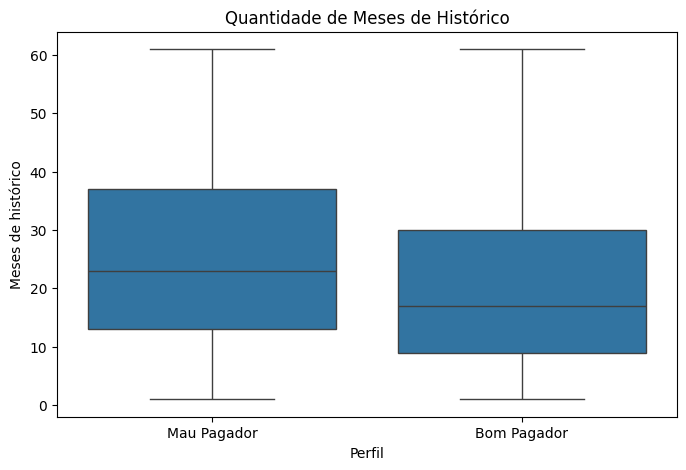

In [ ]:
historico_clientes['PERFIL'] = historico_clientes['TARGET'].map({0: 'Bom Pagador', 1: 'Mau Pagador'})

plt.figure(figsize=(8, 5))

sns.boxplot(data=historico_clientes, x='PERFIL', y='MONTHS_BALANCE')

plt.title('Quantidade de Meses de Histórico')
plt.xlabel('Perfil')
plt.ylabel('Meses de histórico')

plt.show()

**Conclusão:** Os maus pagadores (TARGET = 1) apresentam maior tempo de histórico do que os bons pagadores, tanto pela média quanto pela mediana. Esse resultado indica que clientes observados por mais meses tiveram mais oportunidades de apresentar atraso. Assim, o tempo de histórico pode influenciar a classificação do TARGET.

**Distribuição do Target na população final**

In [ ]:
(df['TARGET'].value_counts(normalize=True) * 100).round(2)

,proportion
TARGET,
0,88.23
1,11.77


**Conclusão:** 88,23% - Bons Pagadores
               11,77% - Maus Pagadores

In [ ]:
df['PERFIL'] = df['TARGET'].map({0: 'Bom Pagador', 1: 'Mau Pagador'})

**2. Distribuição das Variáveis**

**A) RENDA**

***GRÁFICO BOXPLOT***

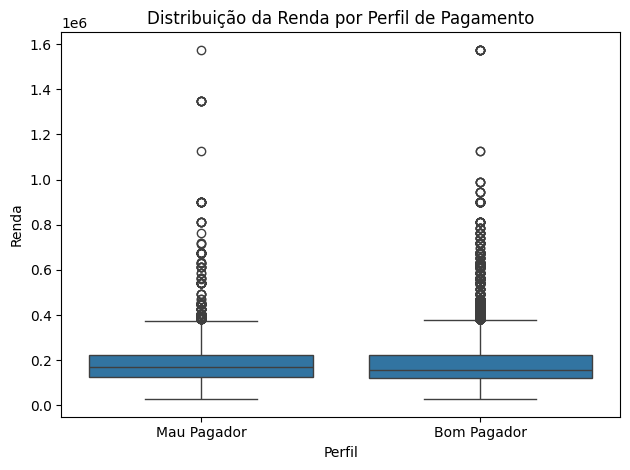

In [ ]:
sns.boxplot(
    x='PERFIL',
    y='AMT_INCOME_TOTAL',
    data=df
)

plt.title('Distribuição da Renda por Perfil de Pagamento')
plt.xlabel('Perfil')
plt.ylabel('Renda')
plt.tight_layout()
plt.show()

**Conclusão**: como as caixas estão em alturas parecidas, pode se concluir que não há uma diferença de renda considerável entre os grupos de bons e maus pagadores. Além disso, as medianas e os intervalos entre quartis aparecem próximos e nos dois grupos observamos diversos valores de renda considerados outliers.

In [ ]:
df.groupby('PERFIL')['AMT_INCOME_TOTAL'].agg(['count', 'mean', 'median']).round(2)

,count,mean,median
PERFIL,,,
Bom Pagador,32166,185785.99,157500.0
Mau Pagador,4291,193430.41,171000.0


**Conclusão**: os maus pagadores apresentam renda média e mediana um pouco superiores às dos bons pagadores. Portanto, maior renda não significa necessariamente menor risco de inadimplência.

**B) IDADE**

In [ ]:
df['IDADE'] = (-df['DAYS_BIRTH'] / 365.25).astype(int)

Transformação da idade de dias para anos.

In [ ]:
df[['DAYS_BIRTH', 'IDADE']].head()

,DAYS_BIRTH,IDADE
0,-12005,32
1,-12005,32
2,-21474,58
3,-19110,52
4,-19110,52


In [ ]:
df['IDADE'].describe().round(2)

,IDADE
count,36457.00
mean,43.23
std,11.50
min,20.00
25%,34.00
50%,42.00
75%,53.00
max,68.00


É possível observar que a idade média dos clientes é 43 anos, mínimo 20 e máximo 68 anos.

***GRÁFICO HISTOGRAMA***

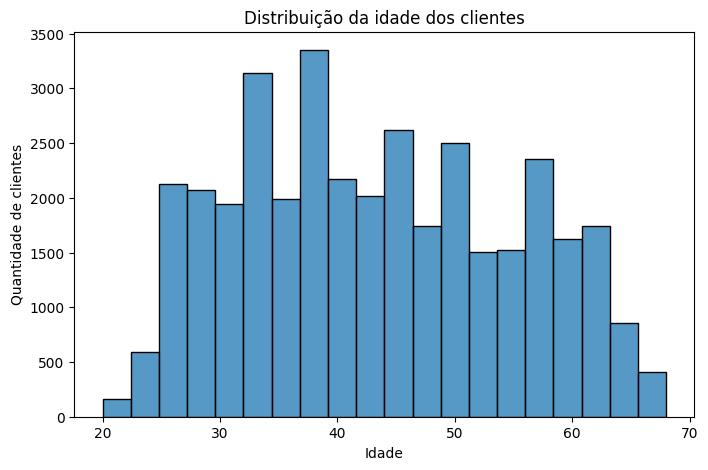

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x='IDADE',
    bins=20
)

plt.title('Distribuição da idade dos clientes')
plt.xlabel('Idade')
plt.ylabel('Quantidade de clientes')

plt.show()

**Conclusão:** A idade dos clientes varia entre 20 e 68 anos, com maior concentração nas faixas intermediárias. Observa-se menor quantidade de clientes nas idades mais extremas.

In [ ]:
df.groupby('PERFIL')['IDADE'].agg(['count', 'mean', 'median']).round(2)

,count,mean,median
PERFIL,,,
Bom Pagador,32166,43.35,42.0
Mau Pagador,4291,42.31,41.0


**Conclusão:** a diferença de idade entre os bons e maus pagadores é pequena. Então a idade, isoladamente, não parece diferenciar os dois perfis de pagamento.

***GRÁFICO BOXPLOT***

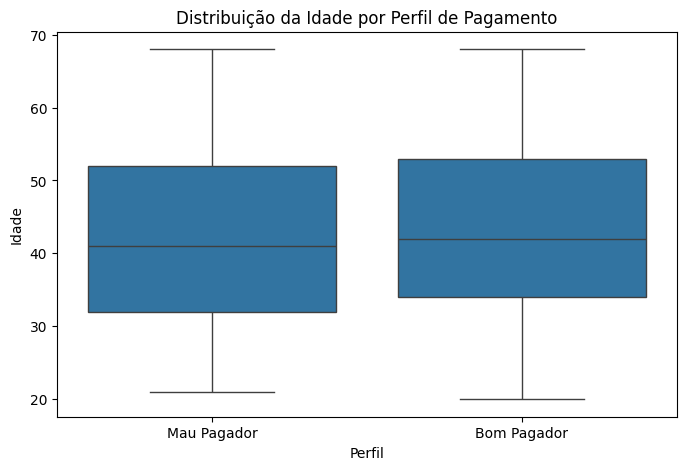

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='PERFIL',
    y='IDADE'
)

plt.title('Distribuição da Idade por Perfil de Pagamento')
plt.xlabel('Perfil')
plt.ylabel('Idade')

plt.show()

**Conclusão:** As distribuições de idade dos bons e maus pagadores são bastante semelhantes. Os maus pagadores apresentam idade média e mediana um pouco inferiores. Conforme já observado no Histograma, a idade isoladamente não demonstra grande capacidade de diferenciar bons e maus pagadores.

**C)TEMPO DE EMPREGO**

In [ ]:
df['DAYS_EMPLOYED'].describe().round(2)

,DAYS_EMPLOYED
count,36457.00
mean,59262.94
std,137651.33
min,-15713.00
25%,-3153.00
50%,-1552.00
75%,-408.00
max,365243.00


In [ ]:
df[df['DAYS_EMPLOYED'] == 365243].shape[0]

6135

In [ ]:
df[df['DAYS_EMPLOYED'] == 365243]['NAME_INCOME_TYPE'].value_counts()

,count
NAME_INCOME_TYPE,
Pensioner,6135


**Conclusão:** Foram identificados 6.135 clientes com DAYS_EMPLOYED = 365243, ou seja, 1.000 anos, valor incompatível. Todos os registros pertencem à categoria Pensioner, indicando que o valor não deve ser considerado como tempo efetivo de emprego, podendo ser um código.


In [ ]:
df['ANOS_EMPREGADO'] = np.where(
    df['DAYS_EMPLOYED'] == 365243,
    np.nan,
    -df['DAYS_EMPLOYED'] / 365.25
)

Foi atribuído "NaN" a todos os clientes com DAYS_EMPLOYED = 365243.

In [ ]:
df['ANOS_EMPREGADO'].describe().round(2)

,ANOS_EMPREGADO
count,30322.00
mean,7.24
std,6.45
min,0.05
25%,2.68
50%,5.45
75%,9.60
max,43.02


**Conclusão:** Desconsiderando os 6135 clientes com 'DAYS_EMPLOYED' 365243, o tempo médio de emprego é de 7,24 anos, com valores variando de aproximadamente 0,05 a 43 anos.

In [ ]:
df.groupby('PERFIL')['ANOS_EMPREGADO'].agg(
    ['count', 'mean', 'median']
).round(2)

,count,mean,median
PERFIL,,,
Bom Pagador,26658,7.25,5.49
Mau Pagador,3664,7.16,5.21


**Conclusão:** O tempo de emprego é muito semelhante entre bons e maus pagadores. Os bons pagadores apresentam média de 7,25 anos, enquanto os maus apresentam 7,16 anos. O tempo de emprego também não parece distinguir de forma relevante os dois perfis.

**GRÁFICO BOXPLOT**

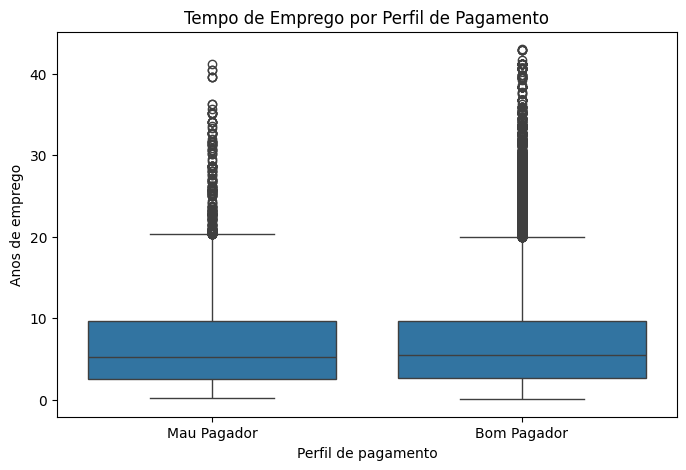

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='PERFIL',
    y='ANOS_EMPREGADO'
)

plt.title('Tempo de Emprego por Perfil de Pagamento')
plt.xlabel('Perfil de pagamento')
plt.ylabel('Anos de emprego')

plt.show()

**Conclusão:** O gráfico mostra mais uma vez que o tempo de emprego apresenta distribuição bastante semelhante entre bons e maus pagadores, com médias de 7,25 e 7,16 anos, respectivamente. O boxplot identifica diversos valores acima de aproximadamente 20 anos (outliers).

**D) QUANTIDADE DE FILHOS**

In [ ]:
df['CNT_CHILDREN'].describe().round(2)

,CNT_CHILDREN
count,36457.00
mean,0.43
std,0.74
min,0.00
25%,0.00
50%,0.00
75%,1.00
max,19.00


In [ ]:
df['CNT_CHILDREN'].value_counts().sort_index()

,count
CNT_CHILDREN,
0,25201
1,7492
2,3256
3,419
4,63
5,20
7,2
14,3
19,1


In [ ]:
df.groupby('PERFIL')['CNT_CHILDREN'].agg(
    ['count', 'mean', 'median']
).round(2)

,count,mean,median
PERFIL,,,
Bom Pagador,32166,0.43,0.0
Mau Pagador,4291,0.45,0.0


In [ ]:
analise_filhos = df.groupby('CNT_CHILDREN').agg(Quantidade=('TARGET', 'count'),
    Taxa_Maus_Pagadores=('TARGET', 'mean'))

analise_filhos['Taxa_Maus_Pagadores'] = (analise_filhos['Taxa_Maus_Pagadores'] * 100).round(2)

analise_filhos

,Quantidade,Taxa_Maus_Pagadores
CNT_CHILDREN,,
0,25201,11.67
1,7492,11.35
2,3256,13.36
3,419,13.13
4,63,7.94
5,20,0.00
7,2,100.00
14,3,66.67
19,1,0.00


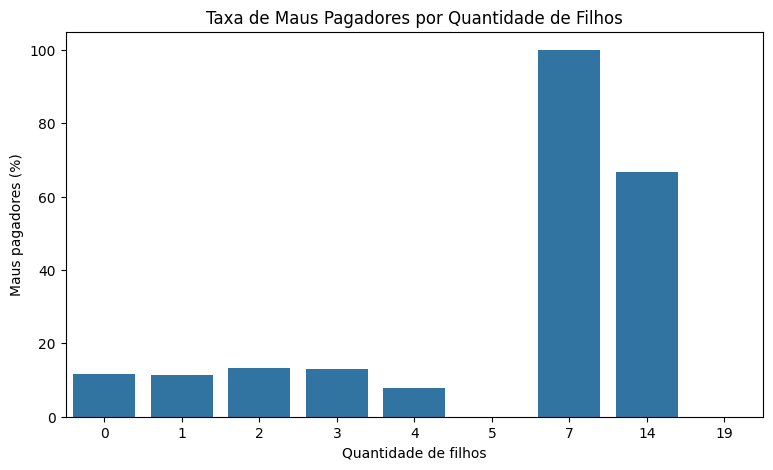

In [ ]:
plt.figure(figsize=(9, 5))

sns.barplot(x=analise_filhos.index,y=analise_filhos['Taxa_Maus_Pagadores'])

plt.title('Taxa de Maus Pagadores por Quantidade de Filhos')
plt.xlabel('Quantidade de filhos')
plt.ylabel('Maus pagadores (%)')

plt.show()

**Conclusão:** A maior parte dos clientes possui entre 0 e 2 filhos. Entre os grupos com maior quantidade de registros, as taxas de maus pagadores são relativamente próximas, variando de 11,35% a 13,36%. Algumas categorias com maior número de filhos apresentam taxas extremas, porém possuem pouquíssimos clientes. De forma geral, a quantidade de filhos, isoladamente, não apresenta uma relação clara com o perfil de pagamento.

**E) TAMANHO DA FAMÍLIA**

In [ ]:
df['CNT_FAM_MEMBERS'].describe().round(2)

,CNT_FAM_MEMBERS
count,36457.00
mean,2.20
std,0.91
min,1.00
25%,2.00
50%,2.00
75%,3.00
max,20.00


As famílias tem em média 2,20 pessoas.

In [ ]:
df['CNT_FAM_MEMBERS'].value_counts().sort_index()

,count
CNT_FAM_MEMBERS,
1.0,6987
2.0,19463
3.0,6421
4.0,3106
5.0,397
6.0,58
7.0,19
9.0,2
15.0,3


In [ ]:
df.groupby('PERFIL')['CNT_FAM_MEMBERS'].agg(['count', 'mean', 'median']).round(2)

,count,mean,median
PERFIL,,,
Bom Pagador,32166,2.20,2.0
Mau Pagador,4291,2.22,2.0


In [ ]:
analise_familia = df.groupby('CNT_FAM_MEMBERS').agg(Quantidade=('TARGET', 'count'),Taxa_Maus_Pagadores=('TARGET', 'mean'))

analise_familia['Taxa_Maus_Pagadores'] = (analise_familia['Taxa_Maus_Pagadores'] * 100).round(2)

analise_familia

,Quantidade,Taxa_Maus_Pagadores
CNT_FAM_MEMBERS,,
1.0,6987,11.81
2.0,19463,11.63
3.0,6421,11.26
4.0,3106,13.62
5.0,397,12.09
6.0,58,8.62
7.0,19,0.00
9.0,2,100.00
15.0,3,66.67


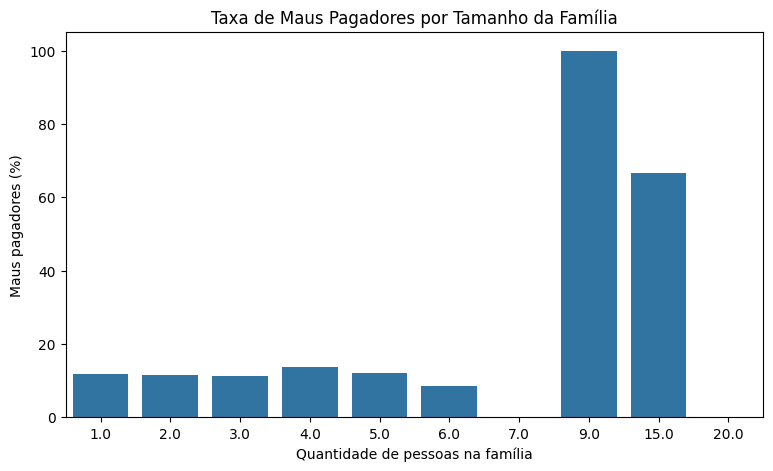

In [ ]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=analise_familia.index,
    y=analise_familia['Taxa_Maus_Pagadores']
)

plt.title('Taxa de Maus Pagadores por Tamanho da Família')
plt.xlabel('Quantidade de pessoas na família')
plt.ylabel('Maus pagadores (%)')

plt.show()

**Conclusão:** A maior parte das famílias tem 2 pessoas. Entre familias com 1 a 5 pessoas, as taxas de maus pagadores são relativamente próximas, variando de 11,26 a 13,62%. As categorias com maior número de pessoas (6 ou mais) representam uma quantidade pequena de famílias, por isso não é atribuída considerável importância. De forma geral, também a quantidade de pessoas em uma família, isoladamente, não apresenta uma relação clara com o perfil de pagamento.

**3) Correlações**

In [ ]:
df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,...,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET,PERFIL,IDADE,ANOS_EMPREGADO
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,1,1,0,0,NaN,2.0,1,Mau Pagador,32,12.435318
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,1,1,0,0,NaN,2.0,1,Mau Pagador,32,12.435318
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,...,1,0,0,0,Security staff,2.0,0,Bom Pagador,58,3.104723
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,1,0,1,1,Sales staff,1.0,0,Bom Pagador,52,8.353183
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,1,0,1,1,Sales staff,1.0,0,Bom Pagador,52,8.353183


In [ ]:
set(df.FLAG_MOBIL)

{1}

In [ ]:
variaveis_correlacao = [
    'CNT_CHILDREN',
    'AMT_INCOME_TOTAL',
    'CNT_FAM_MEMBERS',
    'IDADE',
    'ANOS_EMPREGADO',
    'FLAG_PHONE',
    'TARGET']

Foram excluídas as variáveis 'FLAG_MOBIL' porque não tem variação, todos os registros são 1, a FLAG_WORK_PHONE porque não foi considerada importante, as variáveis que geraram as colunas idade e qtde. de anos de emprego, e ainda as que não são numéricas.

In [ ]:
correlacao = df[variaveis_correlacao].corr().round(2)

print(correlacao)

                  CNT_CHILDREN  AMT_INCOME_TOTAL  CNT_FAM_MEMBERS  IDADE  \
CNT_CHILDREN              1.00              0.03             0.89  -0.34   
AMT_INCOME_TOTAL          0.03              1.00             0.02  -0.07   
CNT_FAM_MEMBERS           0.89              0.02             1.00  -0.30   
IDADE                    -0.34             -0.07            -0.30   1.00   
ANOS_EMPREGADO           -0.06              0.02            -0.04   0.34   
FLAG_PHONE               -0.02              0.02            -0.00   0.03   
TARGET                    0.01              0.02             0.01  -0.03   

                  ANOS_EMPREGADO  FLAG_PHONE  TARGET  
CNT_CHILDREN               -0.06       -0.02    0.01  
AMT_INCOME_TOTAL            0.02        0.02    0.02  
CNT_FAM_MEMBERS            -0.04       -0.00    0.01  
IDADE                       0.34        0.03   -0.03  
ANOS_EMPREGADO              1.00        0.05   -0.00  
FLAG_PHONE                  0.05        1.00   -0.01  
TARGET

**Conclusão:** nenhuma das variáveis analisadas apresentou correlação forte com o Target (Bons ou Maus Pagadores). As variáveis quantidade de filhos e quantidade de membros na família, apresentaram correlação importante (0,89), o que faz todo sentido (mais filhos, logo tem-se maior qtde. de pessoas na família). Uma outra correlação considerável, mas esperada, é a de idade e anos de emprego - pesssoas com mais idade, no geral estão há mais anos no emprego.

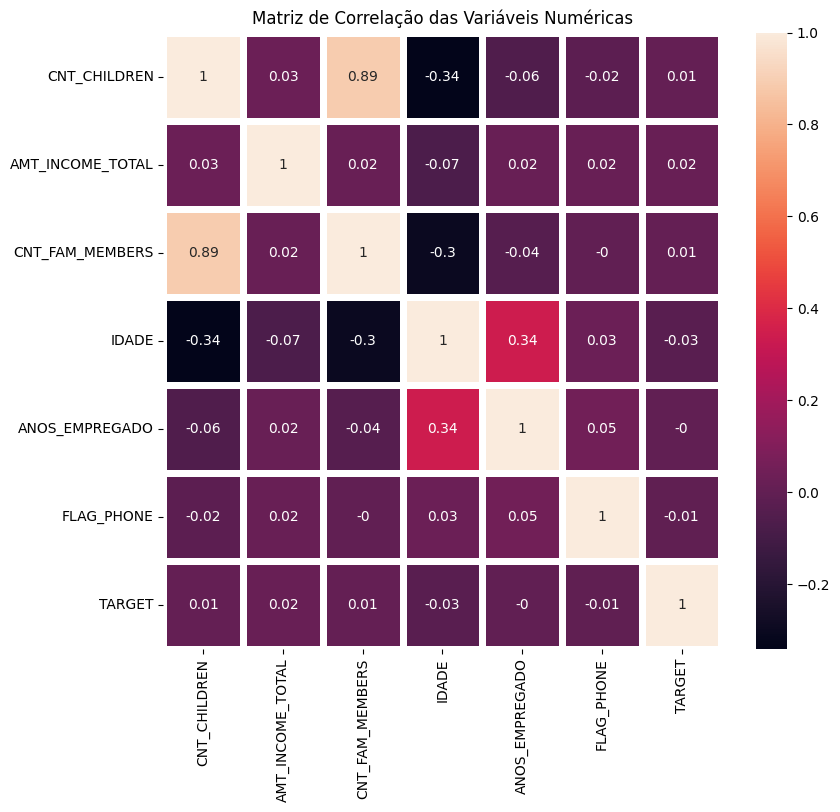

In [ ]:
fig, ax = plt.subplots(figsize=(9,8))

sns.heatmap(correlacao, annot=True, linewidths=5, ax=ax)

plt.title('Matriz de Correlação das Variáveis Numéricas')
plt.show()

**Conclusão:** a matriz de correlação indica que as variáveis numéricas analisadas apresentam pouca correlação com o TARGET, com valores próximos de zero. Sendo assim, nenhuma das variáveis numéricas analisadas, isoladamente, apresenta forte relação com o perfil de pagamento. A maior correlação observada ocorre entre quantidade de filhos (CNT_CHILDREN) e tamanho da família (CNT_FAM_MEMBERS) - 0,89. Também se observa correlação positiva razoável entre idade e tempo de emprego (0,34).

**4) Outliers**

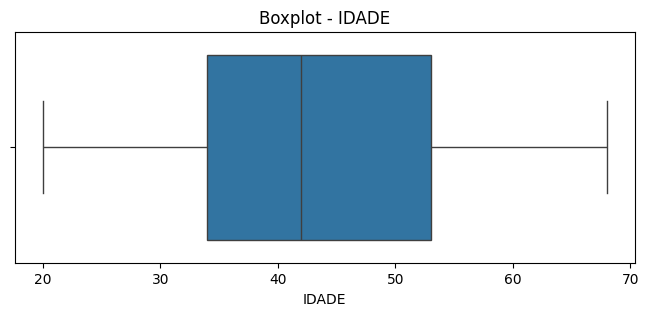

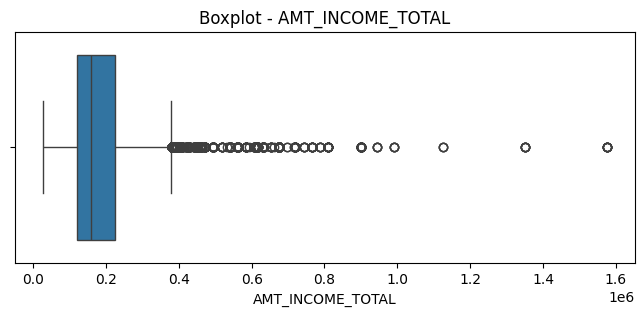

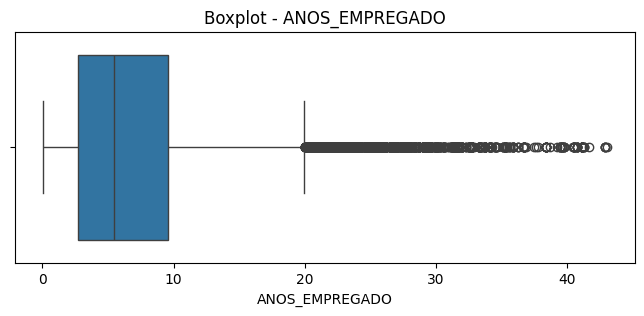

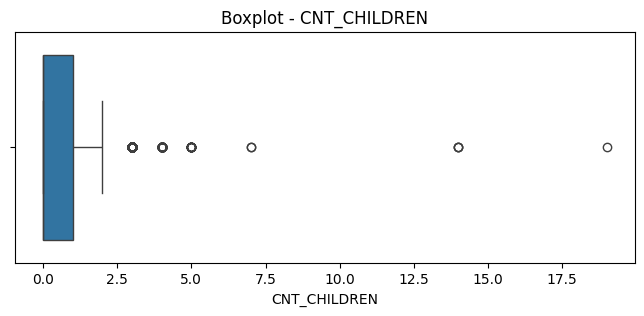

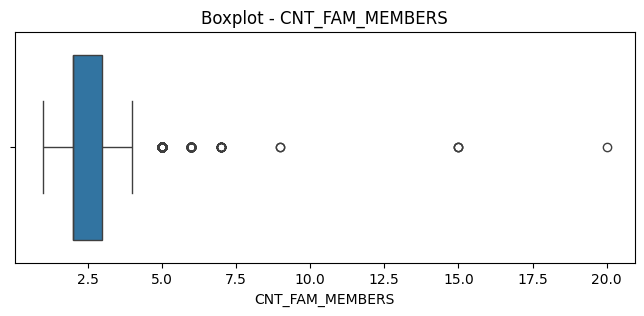

In [ ]:
variaveis_outliers = ['IDADE','AMT_INCOME_TOTAL', 'ANOS_EMPREGADO', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS']

for coluna in variaveis_outliers:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df[coluna])
    plt.title(f'Boxplot - {coluna}')
    plt.show()

**Conclusão:** A análise dos boxplots mostra comportamentos distintos entre as variáveis numéricas. O gráfico da idade não apresenta outliers. Já a renda, o tempo de emprego, a quantidade de filhos e o tamanho da família apresentam valores atipicos relevantes. Os valores serão mantidos nesta etapa e analisados no pré-processamento.

**Conclusão da Análise Exploratória**

A análise exploratória permitiu compreender as principais características da base e definir a população utilizada na modelagem. Após o cruzamento das bases cadastral e de histórico de crédito, foram identificados 36.457 clientes com informações disponíveis em ambas as fontes.

Para a construção do TARGET, foram considerados maus pagadores (TARGET = 1) os clientes que apresentaram atraso igual ou superior a 30 dias em pelo menos um período do histórico. A comparação com um critério de 60 dias mostrou que este último produziria uma quantidade muito reduzida de clientes na classe de maus pagadores, justificando a adoção do limite de 30 dias.

A variável TARGET apresentou desbalanceamento entre as classes, com 88,23% de bons pagadores e 11,77% de maus pagadores. Esse comportamento deverá ser considerado na etapa de modelagem e, principalmente, na escolha das métricas de avaliação, evitando avaliar os modelos apenas pela acurácia.

Também foi observado que os maus pagadores possuem maior período de histórico, tanto pela média quanto pela mediana. Como o TARGET considera a ocorrência de pelo menos um atraso durante todo o período observado, clientes com históricos mais longos tiveram mais oportunidades de apresentar atrasos. Esse aspecto deve ser considerado na interpretação dos resultados.

As análises das características dos clientes mostraram diferenças relativamente pequenas entre bons e maus pagadores quando as variáveis foram observadas individualmente. Da mesma forma, as variáveis numéricas analisadas apresentaram baixa correlação linear com o TARGET, o que não significa necessariamente ausência de capacidade preditiva, uma vez que os modelos podem identificar relações mais complexas entre múltiplas características.

Foram identificados valores ausentes principalmente em OCCUPATION_TYPE, além de valores especiais em DAYS_EMPLOYED, que deverão receber tratamento adequado no pré-processamento. A análise de outliers também identificou valores extremos em renda, tempo de emprego, quantidade de filhos e tamanho da família. Como não foram encontradas evidências suficientes para classificá-los como erros de registro, optou-se por mantê-los nesta etapa.

Com base nesses resultados, a próxima etapa será dedicada ao pré-processamento dos dados, incluindo o tratamento de valores ausentes e especiais, transformação das variáveis, codificação das variáveis categóricas e preparação dos dados para aplicação dos modelos de classificação.

In [ ]:
df.to_csv('base_modelagem.csv', index=False)